In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


%matplotlib inline

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import  GridSearchCV
from sklearn.metrics import classification_report

np.random.seed(42)

### Loading Data

In [51]:
df = pd.read_csv("heart-disease.csv")

### Exploring Data

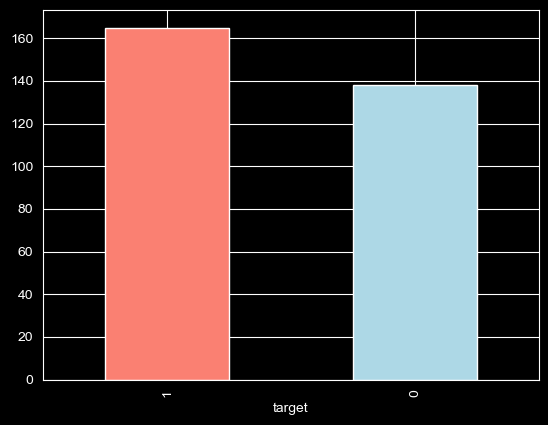

In [52]:
df["target"].value_counts().plot(kind="bar",color=["salmon","lightblue"]);

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [54]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


cp	The type of chest pain the person feels. Different chest pain types can indicate heart problems.	0 = typical chest pain related to heart, 1 = chest pain but not typical, 2 = chest pain not related to heart, 3 = no chest pain symptoms.

trestbps	Blood pressure when the person is resting. Higher values can mean more strain on the heart.	Number in mm Hg (example: 120, 140, 180). Higher = worse.

chol	Amount of cholesterol in the blood (fat in the blood that can block arteries).	Number in mg/dl (example: 200, 300). Higher = more risk.

fbs	Whether the person's blood sugar is high after fasting.	1 = high blood sugar (>120 mg/dl), 0 = normal.

restecg	Result of a heart electrical activity test while resting.	0 = normal, 1 = minor heart rhythm problem, 2 = signs the heart muscle is enlarged.

thalach	The highest heart rate reached during exercise.	Number of beats per minute (example: 150, 170). Lower than expected can indicate heart problems.

exang	Whether exercise causes chest pain.	1 = yes, 0 = no.

old-peak	How much the heart shows stress during exercise compared to rest.	Number like 0.0 – 6.0. Higher = more heart stress.

slope	How the heart activity changes during peak exercise.	0 = improving, 1 = no change, 2 = getting worse.

ca	Number of major heart blood vessels that show blockage in scans.	0–4. Higher = more blocked arteries.

thal	Blood test showing a problem with blood flow to the heart.	0 = normal, 1 = fixed defect (permanent problem), 2 = reversible defect (problem appears during stress).

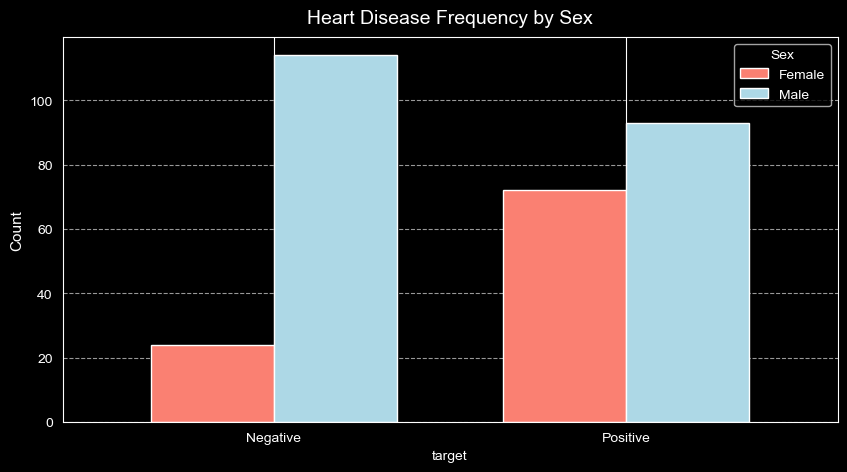

In [55]:
ax = pd.crosstab(df["target"], df["sex"]).plot(
    kind="bar",
    figsize=(10, 5),
    color=["salmon", "lightblue"],
    width=0.7
)

ax.set_title("Heart Disease Frequency by Sex", fontsize=14, pad=10)
ax.set_ylabel("Count", fontsize=11)
ax.set_xticklabels(["Negative", "Positive"], rotation=0)
ax.legend(["Female", "Male"], title="Sex")
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.xticks(rotation=0);


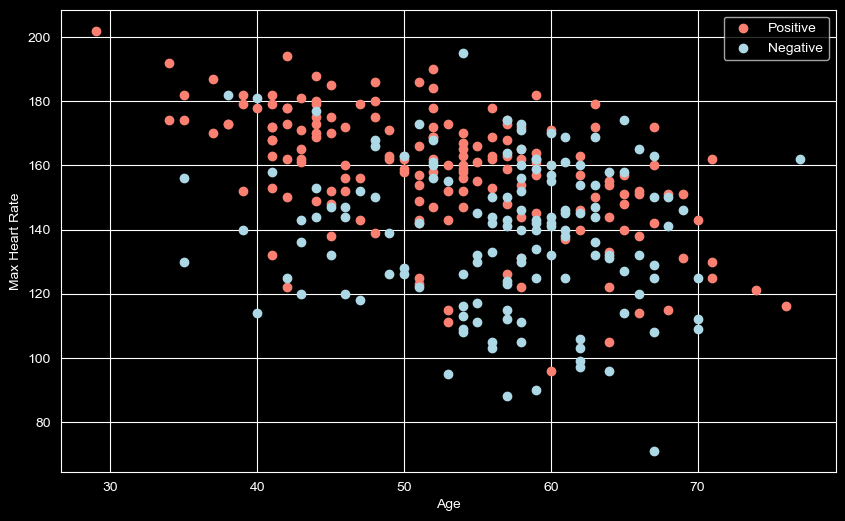

In [56]:
plt.figure(figsize=(10,6))
plt.scatter(df.age[df["target"] == 1],df.thalach[df["target"] == 1],c = "salmon")

plt.scatter(df.age[df["target"] == 0],df.thalach[df["target"] == 0],c= "lightblue")

plt.xlabel("Age")
plt.ylabel("Max Heart Rate")

plt.legend(["Positive","Negative"])


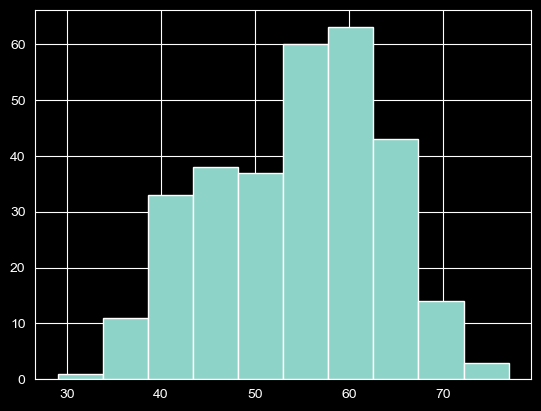

In [57]:
plt.hist(df.age);


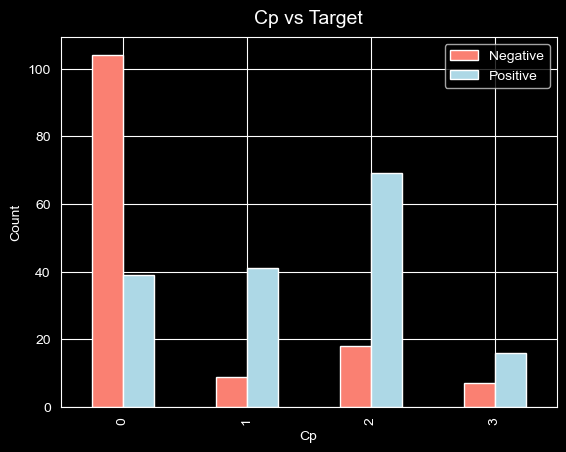

In [58]:
pd.crosstab(df.cp,df.target).plot(kind="bar",color=["salmon", "lightblue"])
plt.title("Cp vs Target", fontsize=14, pad=10)
plt.xlabel("Cp")
plt.ylabel("Count")
plt.legend(["Negative","Positive"]);


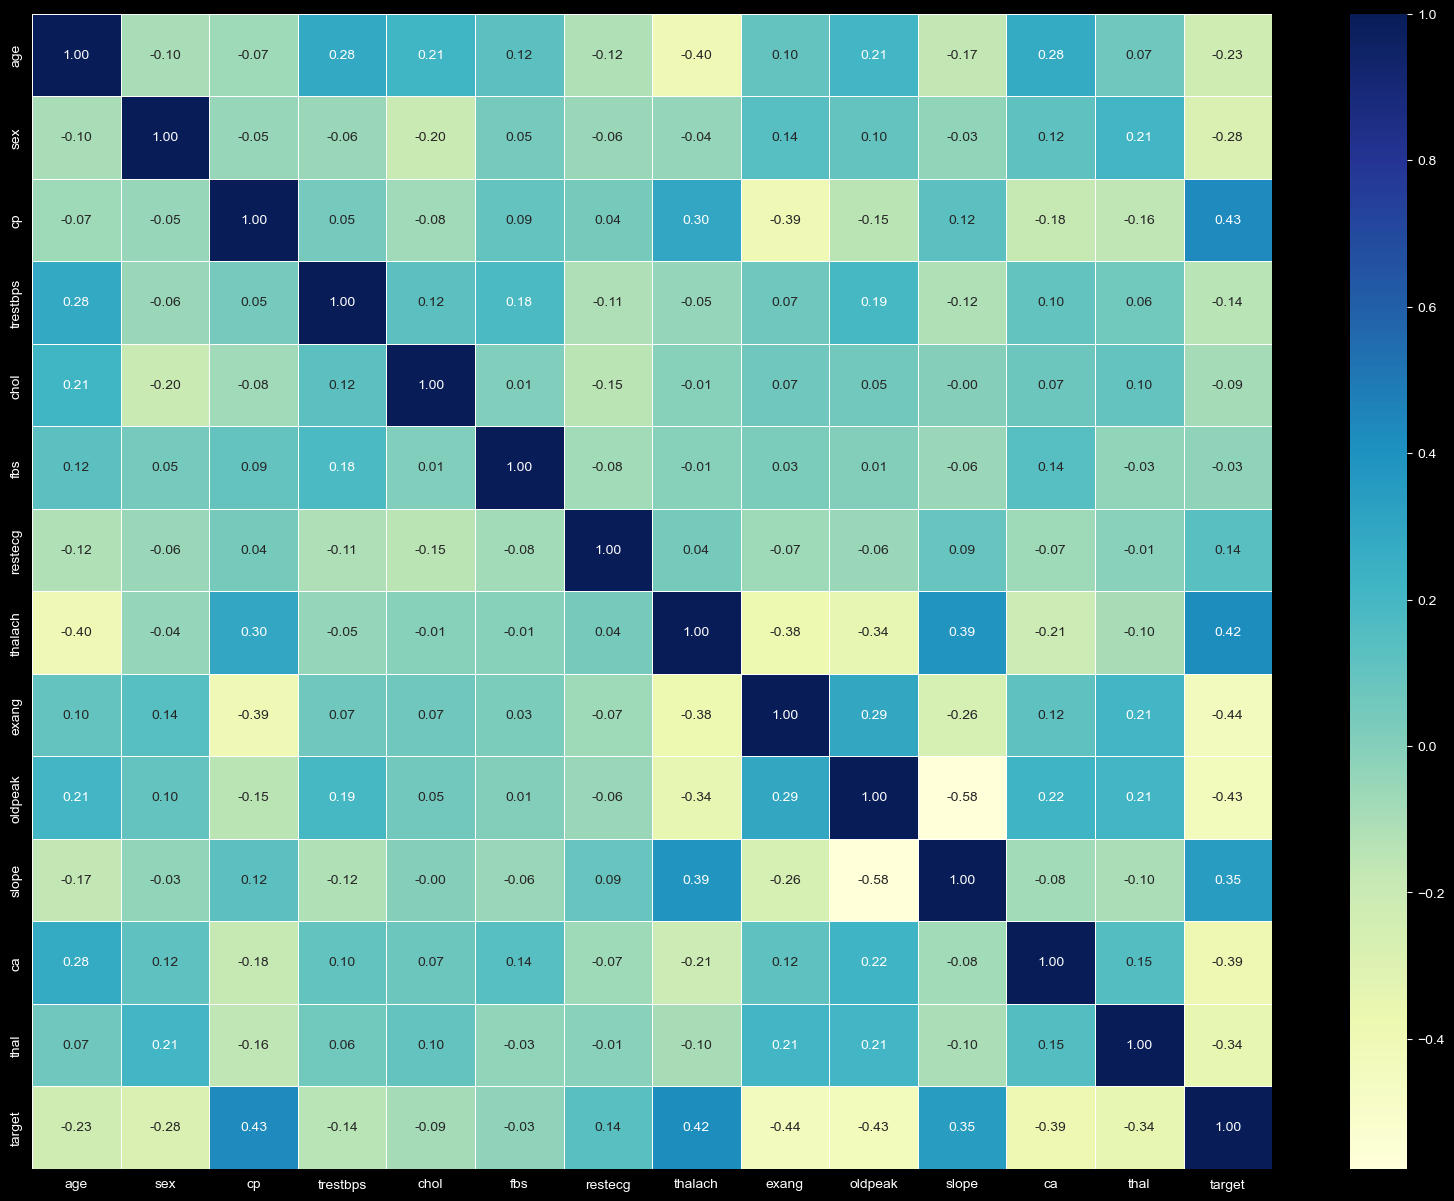

In [59]:
corr_matrix = df.corr()
fig,ax = plt.subplots(figsize=(20,15))
ax = sns.heatmap(corr_matrix,
                 annot=True,
                 linewidths=.5,
                 fmt="0.2f",
                 cmap="YlGnBu",);

### Finding The Best Model
we are going to try :
1. Logistic Regression
2. K-Nearest Neighbors Classifier
3. Random Forest

In [60]:
X = df.drop("target",axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [61]:
model = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
}

def fit_and_score(models,
                  X_train,
                  X_test,
                  y_train,
                  y_test):
    model_scores = {}

    for name, model0 in models.items():
        model0.fit(X_train, y_train)
        model_scores[name] = model0.score(X_test, y_test)

    return model_scores

scores = fit_and_score(model, X_train, X_test, y_train, y_test)

print(scores)

{'Logistic Regression': 0.8688524590163934}


C:\Users\Lenovo\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Tuning HyperParameters

In [62]:
log_reg_grid = {
    "C" : np.logspace(-4,4,30),
    "solver":["liblinear"]
}

rf_grid={
    "n_estimators" : np.arange(10,1000,50),
    "max_depth":[None,3,5,10],
    "min_samples_split":np.arange(2,20,2),
    "min_samples_leaf":np.arange(1,20,2)
}
gs_log_reg = GridSearchCV(LogisticRegression(),param_grid=log_reg_grid,cv=5,verbose=True)
gs_log_reg.fit(X_train,y_train)
var = gs_log_reg.best_params_
print(var)
gs_log_reg.score(X_test,y_test)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
{'C': np.float64(0.20433597178569418), 'solver': 'liblinear'}


0.8852459016393442

### Evaluating

In [63]:
y_preds = gs_log_reg.predict(X_test)
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Fitting 

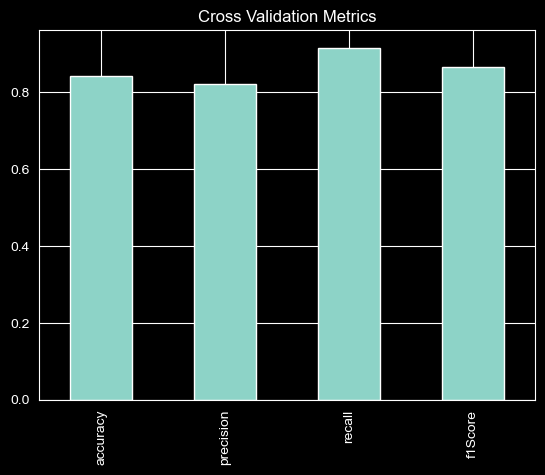

In [64]:
cv_acc = cross_val_score(gs_log_reg, X, y, cv=5, scoring="accuracy")
cv_acc = np.mean(cv_acc)

cv_precision = cross_val_score(gs_log_reg, X, y, cv=5, scoring="precision")
cv_precision = np.mean(cv_precision)


cv_recall = cross_val_score(gs_log_reg, X, y, cv=5, scoring="recall")
cv_recall = np.mean(cv_recall)


cv_f1Score = cross_val_score(gs_log_reg, X, y, cv=5, scoring="f1")
cv_f1Score = np.mean(cv_f1Score)


cv_metrics = pd.DataFrame({
    "accuracy": cv_acc,
    "precision": cv_precision,
    "recall": cv_recall,
    "f1Score": cv_f1Score,
}, index=[0])
cv_metrics.T.plot.bar(title="Cross Validation Metrics", legend=False);


In [66]:
cv_f1Score,cv_acc,cv_recall,cv_precision

(np.float64(0.86406124093473),
 np.float64(0.8413661202185793),
 np.float64(0.9151515151515153),
 np.float64(0.82))

In [68]:
gs_log_reg.best_params_

{'C': np.float64(0.20433597178569418), 'solver': 'liblinear'}

<Axes: >

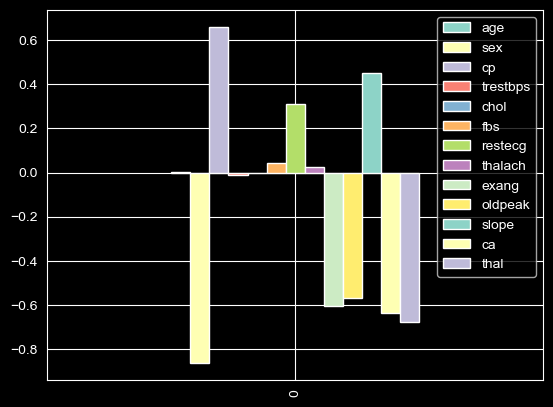

In [73]:
clf = LogisticRegression(C = np.float64(0.20433597178569418), solver =  'liblinear')
clf.fit(X_train,y_train)
feature_dict = dict(zip(df.columns,list(clf.coef_[0])))
feature_df = pd.DataFrame(feature_dict,index=[0])
feature_df.plot(kind="bar")